<a href="https://colab.research.google.com/github/balaji3387/telecom-churn-prediction/blob/main/telecom_churn_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom Customer Churn Prediction
**Tools:** Python, scikit-learn, XGBoost, SHAP, imbalanced-learn

In [ ]:
!pip install xgboost shap imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import warnings
#warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score

from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
import shap

print('Libraries loaded!')

Libraries loaded!


## Step 1: Install & Import Libraries

## Step 2: Load the Dataset

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3: Clean the Data

In [3]:
# Drop customer ID (not useful for prediction)
df.drop(columns=['customerID'], inplace=True)

# Fix TotalCharges column (it's stored as text)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert target column to 0/1
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print('Churn distribution:')
print(df['Churn'].value_counts())
print(f'\nChurn rate: {df["Churn"].mean():.1%}')

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


/tmp/ipykernel_1231/1477369477.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


## Step 4: Feature Engineering (8 new features)

In [4]:
# 1. Charge per month of tenure
df['charge_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# 2. Average monthly spend from total charges
df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'] + 1)

# 3. Service bundle score (how many add-ons does the customer have)
add_ons = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['service_bundle_score'] = df[add_ons].apply(lambda col: (col == 'Yes').astype(int)).sum(axis=1)

# 4. Is on month-to-month contract (highest churn risk)
df['is_month_to_month'] = (df['Contract'] == 'Month-to-month').astype(int)

# 5. Senior citizen living alone (no partner, no dependents)
df['senior_alone'] = ((df['SeniorCitizen'] == 1) & (df['Partner'] == 'No') & (df['Dependents'] == 'No')).astype(int)

# 6. Tenure bucket: early / mid / long-term customer
df['tenure_bucket'] = pd.cut(df['tenure'], bins=[0, 12, 36, 72], labels=['early', 'mid', 'long']).astype(str)

# 7. High monthly charge flag (top 25%)
df['high_monthly_charge'] = (df['MonthlyCharges'] > df['MonthlyCharges'].quantile(0.75)).astype(int)

# 8. Many services but no tech support
df['services_no_support'] = ((df['service_bundle_score'] >= 3) & (df['TechSupport'] == 'No')).astype(int)

print('8 new features added!')
print('Total columns now:', df.shape[1])

8 new features added!
Total columns now: 28


## Step 5: Prepare Data for Modeling

In [5]:
# Split features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Identify column types
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Build preprocessor (scale numbers, encode categories)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply preprocessing
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 5634 | Test size: 1409


## Step 6: Handle Class Imbalance — SMOTE + Tomek Links

In [6]:
print('Before resampling:', dict(zip(*np.unique(y_train, return_counts=True))))

smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X_train_proc, y_train)

print('After resampling: ', dict(zip(*np.unique(y_resampled, return_counts=True))))

Before resampling: {np.int64(0): np.int64(4139), np.int64(1): np.int64(1495)}
After resampling:  {np.int64(0): np.int64(3979), np.int64(1): np.int64(3979)}


## Step 7: Benchmark 3 Models — 5-Fold Cross Validation

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    auc = cross_val_score(model, X_resampled, y_resampled, cv=cv, scoring='roc_auc').mean()
    f1  = cross_val_score(model, X_resampled, y_resampled, cv=cv, scoring='f1').mean()
    print(f'{name:25s}  AUC: {auc:.3f}  F1: {f1:.3f}')

Logistic Regression        AUC: 0.866  F1: 0.790
Random Forest              AUC: 0.946  F1: 0.879


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:31:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:31:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:31:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:31:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost                    AUC: 0.943  F1: 0.866


## Step 8: Train Final Model (XGBoost) & Evaluate

In [8]:
# Train XGBoost on resampled data
model = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                      use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_resampled, y_resampled)

# Predict on test set
y_pred  = model.predict(X_test_proc)
y_proba = model.predict_proba(X_test_proc)[:, 1]

print(f'AUC:    {roc_auc_score(y_test, y_proba):.2f}')
print(f'F1:     {f1_score(y_test, y_pred):.2f}')
print(f'Recall: {recall_score(y_test, y_pred):.2f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:31:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC:    0.83
F1:     0.60
Recall: 0.61

              precision    recall  f1-score   support

    No Churn       0.86      0.84      0.85      1035
       Churn       0.58      0.61      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.78      0.78      0.78      1409



## Step 9: SHAP Explainability

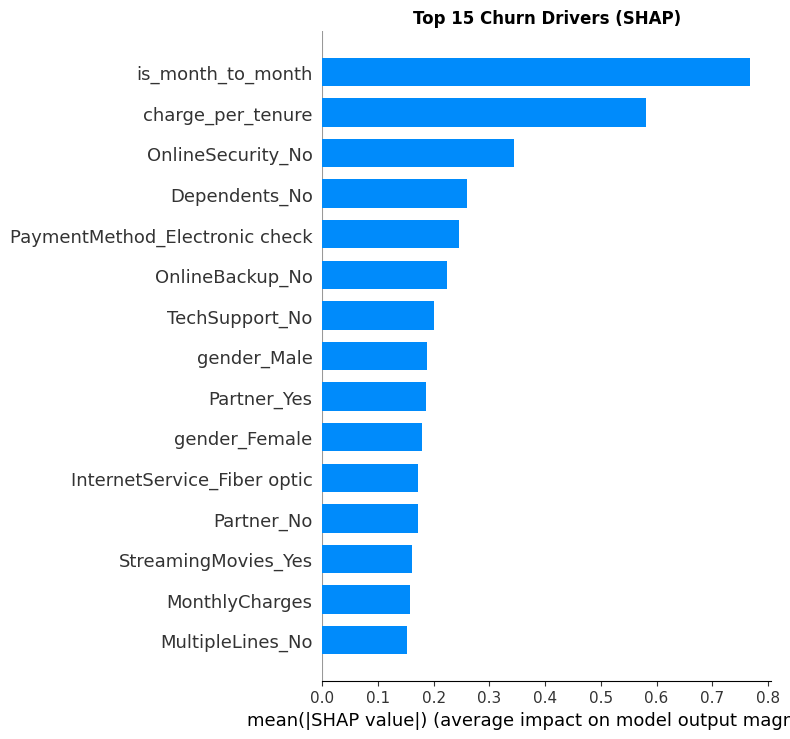

In [9]:
# Get feature names after encoding
ohe_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + ohe_names

# Compute SHAP values
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_proc)

# Global feature importance (bar chart)
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test_proc, feature_names=feature_names, plot_type='bar', max_display=15, show=False)
plt.title('Top 15 Churn Drivers (SHAP)', fontweight='bold')
plt.tight_layout()
plt.show()

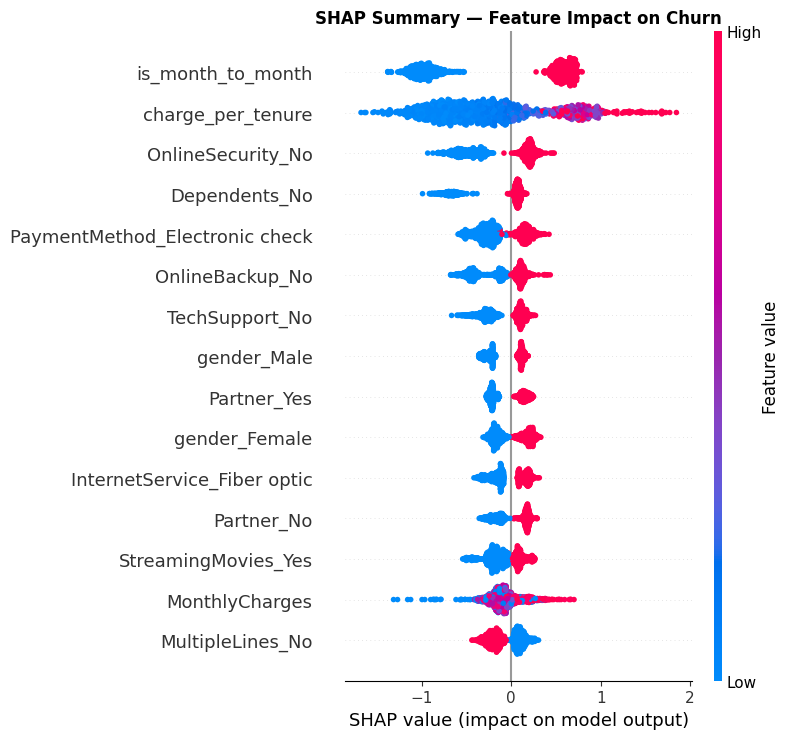

In [10]:
# SHAP beeswarm summary (shows direction of impact)
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test_proc, feature_names=feature_names, max_display=15, show=False)
plt.title('SHAP Summary — Feature Impact on Churn', fontweight='bold')
plt.tight_layout()
plt.show()

Churn probability: 98.4%
Actual label: Churn


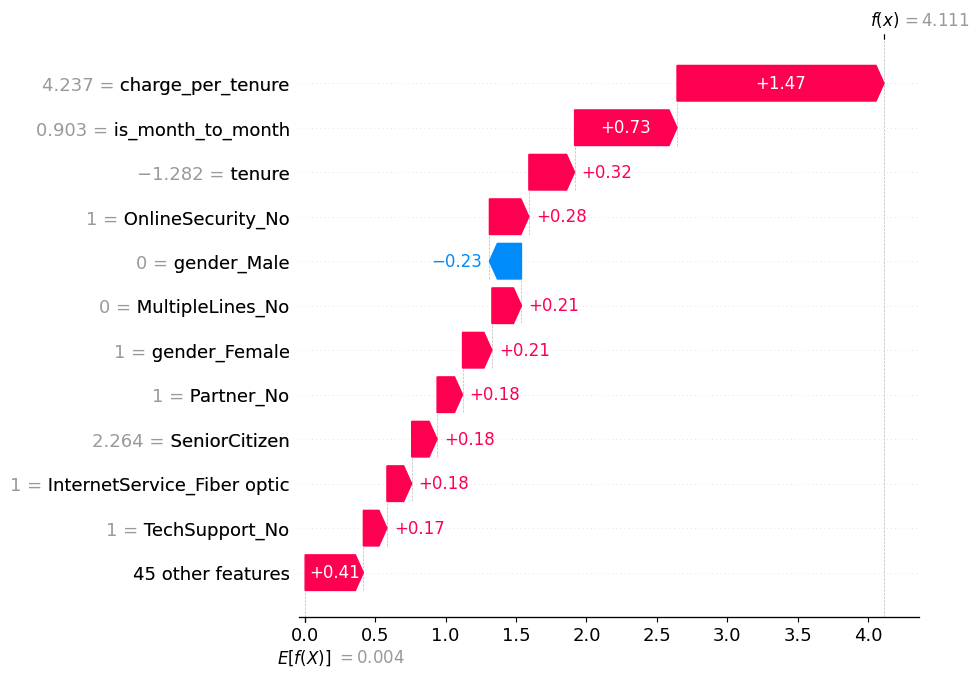

In [11]:
# Explain one high-risk customer
high_risk_idx = np.argmax(y_proba)  # customer with highest churn probability

print(f'Churn probability: {y_proba[high_risk_idx]:.1%}')
print(f'Actual label: {"Churn" if y_test.iloc[high_risk_idx] == 1 else "No Churn"}')

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_proc[high_risk_idx],
        feature_names=feature_names
    ),
    max_display=12
)

## Step 10: Save Pipeline for Production

In [12]:
import joblib

# Save preprocessor + model together
joblib.dump({'preprocessor': preprocessor, 'model': model}, 'churn_pipeline.pkl')
print('Pipeline saved!')

# Load and run inference on new raw data
loaded = joblib.load('churn_pipeline.pkl')

new_customers = X_test.iloc[:5].copy()
probs = loaded['model'].predict_proba(loaded['preprocessor'].transform(new_customers))[:, 1]

for i, p in enumerate(probs):
    risk = 'HIGH RISK' if p > 0.6 else ('MEDIUM' if p > 0.3 else 'LOW')
    print(f'Customer {i+1}: {p:.1%} churn probability → {risk}')

Pipeline saved!
Customer 1: 0.8% churn probability → LOW
Customer 2: 87.8% churn probability → HIGH RISK
Customer 3: 5.1% churn probability → LOW
Customer 4: 19.0% churn probability → LOW
Customer 5: 0.8% churn probability → LOW
